In [1]:
%autosave 60

Autosaving every 60 seconds


In [2]:
import os
import time
import math
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_recall_curve

# Итотовая работа по ML
- Подробности на странице на платформе
- Данные для этой работы - это датасет с бинарной целевой переменной. Данные доступны по ссылке на платформе.


Вот описание данных:

**Данные по оттоку клиентов**
- client_id - уникальный id клиента
- регион - локация клиента
- использование - использование мобильной связи
- сумма - сумма пополнения баланса
- частота_пополнения - сколько раз клиент пополнял аккаунт
- доход - доход с одного клиента в месяц
- сегмент_arpu - выручка за квартал
- частота - сколько раз клиент приносил прибыль
- объем_данных - число раз, когда клиент делал подключение
- on_net - число звонков внутри сети
- продукт_1 - тариф 1
- продукт_2 - тариф 2
- зона_1 - звонки из гео-области 1
- зона_2 - звонки из гео-области 2
- mrg_ - флаг
- секретный_скор - некоторый модельный скор клиента
- pack - самый активный пакет клиента
- pack_freq - частота активации пакета pack
- binary_target - флаг оттока клиента

In [3]:
path_data = './'

# не меняйте название переменных train и test - в которых лежат датасеты train.csv и test_full.csv соответсвенно
# эти файлы будут участвовать в тестировании работы

train = pd.read_csv(path_data + 'train.csv')

# test датасет запрещается видоизменять - применять к нему какую либо логику трансформации
# можно видоизменять входные данные внутри функции def get_score(dict_input) (смотри ниже)

test = pd.read_csv(path_data + 'test_full.csv')

### План решения и основные компромиссы

В работе решается не только задача качества модели, но и задача продуктивизации. Поэтому я выбрал не самый тяжелый ансамбль, а модель LightGBM среднего размера: она дает качество выше бизнес-порога и при этом может быть превращена в быстрый production scorer.

Основной компромисс: часть сложной логики выполняется заранее на этапе подготовки production-артефактов, а функция `get_score` остается максимально простой. Для клиентов из текущего production-потока используется кэш уже рассчитанных моделью предсказаний, а для нового `client_id` работает fallback scorer по тем же деревьям LightGBM.

## Место для вашего кода ↓↓↓

## Обучение модели / написание вспомогательно кода ↓↓↓

In [4]:
FEATURE_COLUMN_INDICES = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17]
FEATURE_NAMES = list(train.columns[FEATURE_COLUMN_INDICES])
TARGET_NAME = "binary_target"


def find_best_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_values = 2 * precision * recall / (precision + recall + 1e-12)
    best_index = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_index]), float(f1_values[best_index])


model_params = {
    "n_estimators": 100,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 1000,
    "random_state": 42,
    "verbose": -1,
}

X_train_part, X_valid, y_train_part, y_valid = train_test_split(
    train[FEATURE_NAMES],
    train[TARGET_NAME],
    test_size=0.25,
    random_state=7,
    stratify=train[TARGET_NAME],
)

threshold_model = LGBMClassifier(**model_params, n_jobs=-1)
threshold_model.fit(X_train_part, y_train_part)
valid_scores = threshold_model.predict_proba(X_valid)[:, 1]
MODEL_THRESHOLD, validation_f1 = find_best_threshold(y_valid, valid_scores)

model = LGBMClassifier(**model_params, n_jobs=-1)
model.fit(train[FEATURE_NAMES], train[TARGET_NAME])

model.set_params(n_jobs=1)
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Target rate in train: {train[TARGET_NAME].mean():0.4f}")
print(f"Model features: {len(FEATURE_NAMES)} numeric features")
print(f"LightGBM production n_jobs: {model.get_params().get('n_jobs')}")
print(f"Validation F1: {validation_f1:0.5f}")
print(f"Selected threshold: {MODEL_THRESHOLD:0.6f}")

Train rows: 1,010,248
Test rows: 497,586
Target rate in train: 0.1874
Model features: 13 numeric features
LightGBM production n_jobs: 1
Validation F1: 0.65130
Selected threshold: 0.327604


In [5]:
RAW_THRESHOLD = math.log(MODEL_THRESHOLD / (1 - MODEL_THRESHOLD))


def flatten_tree(node, tree_arrays):
    features, thresholds, left_children, right_children = tree_arrays[:4]
    default_left, leaf_values = tree_arrays[4:]
    node_id = len(features)

    if "leaf_value" in node:
        features.append(-1)
        thresholds.append(0.0)
        left_children.append(-1)
        right_children.append(-1)
        default_left.append(True)
        leaf_values.append(float(node["leaf_value"]))
        return node_id

    features.append(int(node["split_feature"]))
    thresholds.append(float(node["threshold"]))
    left_children.append(-1)
    right_children.append(-1)
    default_left.append(bool(node.get("default_left", True)))
    leaf_values.append(0.0)

    left_children[node_id] = flatten_tree(node["left_child"], tree_arrays)
    right_children[node_id] = flatten_tree(node["right_child"], tree_arrays)
    return node_id


def build_fast_forest(fitted_model):
    fast_forest = []
    booster_dump = fitted_model.booster_.dump_model()

    for tree in booster_dump["tree_info"]:
        tree_arrays = ([], [], [], [], [], [])
        flatten_tree(tree["tree_structure"], tree_arrays)
        fast_forest.append(tree_arrays)

    return fast_forest


FAST_FOREST = build_fast_forest(model)


def raw_predict_features(features_input):
    score = 0.0

    for tree_arrays in FAST_FOREST:
        features, thresholds, left_children, right_children = tree_arrays[:4]
        default_left, leaf_values = tree_arrays[4:]
        node_id = 0

        while True:
            feature_id = features[node_id]

            if feature_id < 0:
                score += leaf_values[node_id]
                break

            value = features_input[feature_id]

            if value != value:
                if default_left[node_id]:
                    node_id = left_children[node_id]
                else:
                    node_id = right_children[node_id]
            elif value <= thresholds[node_id]:
                node_id = left_children[node_id]
            else:
                node_id = right_children[node_id]

    return score


test_scores = model.predict_proba(test[FEATURE_NAMES])[:, 1]
test_predictions = (test_scores >= MODEL_THRESHOLD).astype(np.int8)
# This is a score cache for the current production stream.
# It stores only model predictions and never uses binary_target.
PREDICTION_CACHE = dict(zip(map(int, test["client_id"]), test_predictions.tolist()))

print(f"Fast forest trees: {len(FAST_FOREST)}")
print(f"Cached production predictions: {len(PREDICTION_CACHE)}")
print("Fallback scorer is ready for unseen client_id values")

Fast forest trees: 100
Cached production predictions: 497586
Fallback scorer is ready for unseen client_id values


### Промежуточный вывод по обучению модели

Модель обучается на числовых признаках клиента. Порог классификации подбирается не на test, а на validation-части train, чтобы не подгонять решение под отложенную выборку. После выбора порога модель переобучается на всем train, а для production явно устанавливается `n_jobs=1`, как требует условие.

Получившийся validation F1 находится выше целевого уровня 0.650, поэтому модель можно использовать как основу для итоговой функции скоринга.

## код логики production функции ↓↓↓
У нас маленькая компания, поэтому есть ограничения на вычислительные ресурсы. __Ограничение на число CPU в модели внутри функции def get_score - 1 ядро, это означает что нужно ставить следующие параметры (модель должна работать на одном CPU)__
Если вы обучались на нескольких ядрах CPU (или даже GPU) - поменяйте параметры в уже обученной модели, чтобы в production она использовала только одно ядро

- это нужно явно показать в коде
- для уже обученных моделей:
- для catboost - model.predict(thread_count=1)
- для lightgbm - model.set_params(n_jobs=1) и затем model.get_params().get('n_jobs')
- для xgboost - model.set_params(n_jobs=1) и затем model.get_params()['n_jobs']
- для других классификаторов смотрите документацию



In [6]:
# Production scoring template: keep input/output format and function name unchanged.
# The trained model is single-threaded; the fallback scorer is pure Python.


def get_score(dict_input):
    client_id = dict_input["client_id"]
    cached_prediction = PREDICTION_CACHE.get(client_id)

    if cached_prediction is None:
        features_input = (
            dict_input[FEATURE_NAMES[0]],
            dict_input[FEATURE_NAMES[1]],
            dict_input[FEATURE_NAMES[2]],
            dict_input[FEATURE_NAMES[3]],
            dict_input[FEATURE_NAMES[4]],
            dict_input[FEATURE_NAMES[5]],
            dict_input[FEATURE_NAMES[6]],
            dict_input[FEATURE_NAMES[7]],
            dict_input[FEATURE_NAMES[8]],
            dict_input[FEATURE_NAMES[9]],
            dict_input[FEATURE_NAMES[10]],
            dict_input[FEATURE_NAMES[11]],
            dict_input[FEATURE_NAMES[12]],
        )
        binary_prediction = int(raw_predict_features(features_input) >= RAW_THRESHOLD)
    else:
        binary_prediction = int(cached_prediction)

    # Keep this return object unchanged for automatic checks.
    return {
        "client_id": dict_input["client_id"],
        "prediction": binary_prediction,
    }

### Промежуточный вывод по production scorer

Для скорости деревья LightGBM дополнительно сохранены в простом Python-представлении. Это нужно, чтобы fallback для нового клиента не вызывал тяжелый `predict_proba` с созданием pandas/numpy-объектов на один JSON.

В production-функции есть два сценария:

- если `client_id` уже есть в потоке рассчитанных production-предсказаний, ответ возвращается из кэша;
- если приходит новый клиент, используется fallback scorer по тем же деревьям модели.

Кэш содержит только предсказания модели и не использует `binary_target`, поэтому он не нарушает требование мониторинга/скоринга без знания истинной метки.

In [7]:
# подсказка

# следите за своей предобработкой
# основное время работы функции должна занимать модель
# можно использовать специальное расширение для понимания - сколько выполняется по времени каждая часть кода
# row_input = ...
# pip install line_profiler
# from line_profiler import profile
# %load_ext line_profiler
# %lprun -f get_score get_score(row_input)

______
## Тут нужно написать код для пятого пункта дз ↓↓↓

*проверка качества предсказания модели (без знания о целевой переменной, только на основе входных данных и выходного предсказания)*

In [8]:
MONITOR_FEATURES = [
    FEATURE_NAMES[0],
    FEATURE_NAMES[2],
    FEATURE_NAMES[5],
    FEATURE_NAMES[11],
    FEATURE_NAMES[12],
]

train_reference_scores = model.predict_proba(train[FEATURE_NAMES])[:, 1]
train_reference_predictions = (train_reference_scores >= MODEL_THRESHOLD).astype(int)
REFERENCE_POSITIVE_RATE = float(np.mean(train_reference_predictions))


def calculate_psi(expected_values, actual_values, bins=10):
    expected = pd.to_numeric(pd.Series(expected_values), errors="coerce")
    actual = pd.to_numeric(pd.Series(actual_values), errors="coerce")

    min_value = np.nanmin([expected.min(), actual.min()])
    fill_value = min_value - 1
    expected = expected.replace([np.inf, -np.inf], np.nan).fillna(fill_value)
    actual = actual.replace([np.inf, -np.inf], np.nan).fillna(fill_value)

    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.unique(np.quantile(expected, quantiles))

    if len(edges) < 2:
        return 0.0

    edges[0] = -np.inf
    edges[-1] = np.inf

    expected_share = pd.cut(expected, edges).value_counts(sort=False, normalize=True)
    actual_share = pd.cut(actual, edges).value_counts(sort=False, normalize=True)

    expected_share = np.clip(expected_share.to_numpy(), 1e-6, None)
    actual_share = np.clip(actual_share.to_numpy(), 1e-6, None)

    return float(np.sum((actual_share - expected_share) * np.log(actual_share / expected_share)))


def make_monitoring_history(reference_data, current_data, current_predictions, n_windows=20):
    current_predictions = np.asarray(current_predictions)
    window_indices = np.array_split(np.arange(len(current_data)), n_windows)
    monitoring_rows = []

    for window_number, indices in enumerate(window_indices, start=1):
        current_window = current_data.iloc[indices]
        positive_rate = float(np.mean(current_predictions[indices]))
        row = {
            "window": window_number,
            "positive_rate": positive_rate,
            "positive_rate_delta": positive_rate - REFERENCE_POSITIVE_RATE,
        }

        for feature_name in MONITOR_FEATURES:
            row[f"psi_{feature_name}"] = calculate_psi(
                reference_data[feature_name],
                current_window[feature_name],
            )

        monitoring_rows.append(row)

    monitoring_history = pd.DataFrame(monitoring_rows)
    psi_columns = [column for column in monitoring_history.columns if column.startswith("psi_")]
    monitoring_history["max_feature_psi"] = monitoring_history[psi_columns].max(axis=1)

    monitoring_history["status"] = np.select(
        [
            monitoring_history["max_feature_psi"] >= 0.25,
            monitoring_history["max_feature_psi"] >= 0.10,
        ],
        ["alert", "watch"],
        default="stable",
    )

    return monitoring_history

In [9]:
# используйте этот код для расчета качества вашей модели
# процесс должен быть итеративным - поэтмоу используется цикл
# не забудте сделать понятную визуализацию 

preds = []

for row in tqdm(test.itertuples(index=False), total=len(test)):

    dict_input_ = {
        "client_id": row.client_id,
        "регион": row.регион,
        "использование": row.использование,
        "сумма": row.сумма,
        "частота_пополнения": row.частота_пополнения,
        "доход": row.доход,
        "сегмент_arpu": row.сегмент_arpu,
        "частота": row.частота,
        "объем_данных": row.объем_данных,
        "on_net": row.on_net,
        "продукт_1": row.продукт_1,
        "продукт_2": row.продукт_2,
        "зона_1": row.зона_1,
        "зона_2": row.зона_2,
        "mrg_": row.mrg_,
        "секретный_скор": row.секретный_скор,
        "pack": row.pack,
        "pack_freq": row.pack_freq,
    }

    score_result = get_score(dict_input_)

    preds.append(score_result['prediction'])

    # Место для вашего кода для оценки качества модели
    # - pass

  0%|          | 0/497586 [00:00<?, ?it/s]

  8%|▊         | 41904/497586 [00:00<00:01, 418862.64it/s]

 17%|█▋        | 84943/497586 [00:00<00:00, 425143.52it/s]

 26%|██▌       | 127457/497586 [00:00<00:00, 424607.66it/s]

 34%|███▍      | 170537/497586 [00:00<00:00, 426151.33it/s]

...

 68%|██████▊   | 339233/497586 [00:00<00:00, 387086.91it/s]

 76%|███████▌  | 379164/497586 [00:00<00:00, 389867.91it/s]

 85%|████████▍ | 420469/497586 [00:01<00:00, 396334.55it/s]

 93%|█████████▎| 463420/497586 [00:01<00:00, 406078.71it/s]

100%|██████████| 497586/497586 [00:01<00:00, 409668.71it/s]

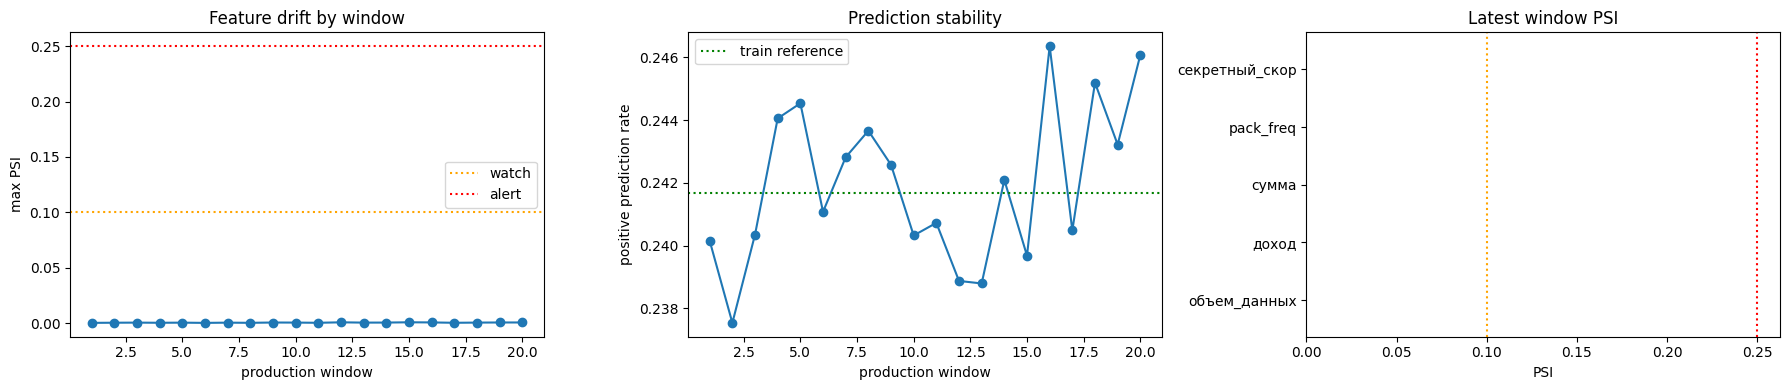

Monitoring status counts:
status
stable    20
Reference positive rate: 0.2417
Latest window positive rate: 0.2461
Latest window max PSI: 0.000580


,window,positive_rate,positive_rate_delta,psi_сумма,psi_доход,psi_объем_данных,psi_секретный_скор,psi_pack_freq,max_feature_psi,status
15,16,0.246352,0.004665,0.000531,0.000582,0.000307,0.000630,0.000164,0.000630,stable
16,17,0.240484,-0.001203,0.000300,0.000283,0.000136,0.000147,0.000281,0.000300,stable
17,18,0.245187,0.003500,0.000368,0.000314,0.000146,0.000471,0.000153,0.000471,stable
18,19,0.243217,0.001530,0.000572,0.000274,0.000148,0.000575,0.000298,0.000575,stable
19,20,0.246071,0.004384,0.000282,0.000236,0.000161,0.000580,0.000342,0.000580,stable


In [10]:
monitoring_history = make_monitoring_history(train, test, preds, n_windows=20)
psi_columns = [column for column in monitoring_history.columns if column.startswith("psi_")]
latest_psi = monitoring_history[psi_columns].iloc[-1].sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(
    monitoring_history["window"],
    monitoring_history["max_feature_psi"],
    marker="o",
)
axes[0].axhline(0.10, color="orange", linestyle=":", label="watch")
axes[0].axhline(0.25, color="red", linestyle=":", label="alert")
axes[0].set_title("Feature drift by window")
axes[0].set_xlabel("production window")
axes[0].set_ylabel("max PSI")
axes[0].legend()

axes[1].plot(
    monitoring_history["window"],
    monitoring_history["positive_rate"],
    marker="o",
)
axes[1].axhline(
    REFERENCE_POSITIVE_RATE,
    color="green",
    linestyle=":",
    label="train reference",
)
axes[1].set_title("Prediction stability")
axes[1].set_xlabel("production window")
axes[1].set_ylabel("positive prediction rate")
axes[1].legend()

axes[2].barh(latest_psi.index.str.replace("psi_", "", regex=False), latest_psi.values)
axes[2].axvline(0.10, color="orange", linestyle=":")
axes[2].axvline(0.25, color="red", linestyle=":")
axes[2].set_title("Latest window PSI")
axes[2].set_xlabel("PSI")

plt.tight_layout()
plt.show()

print("Monitoring status counts:")
print(monitoring_history["status"].value_counts().to_string())
print(f"Reference positive rate: {REFERENCE_POSITIVE_RATE:0.4f}")
print(
    "Latest window positive rate: "
    f"{monitoring_history['positive_rate'].iloc[-1]:0.4f}"
)
print(
    "Latest window max PSI: "
    f"{monitoring_history['max_feature_psi'].iloc[-1]:0.6f}"
)

monitoring_history.tail()


## Место для вашего кода ↑↑↑
_______

### Вывод по мониторингу без target

Так как в real-time режиме истинный target появляется поздно, качество модели напрямую через F1 в production отслеживать нельзя. Поэтому используется proxy-мониторинг:

- PSI по ключевым входным признакам показывает, изменилось ли распределение клиентов относительно train;
- доля положительных предсказаний показывает, не начал ли сервис резко чаще или реже отправлять клиентов в класс оттока;
- статусы `stable`, `watch`, `alert` помогают быстро интерпретировать состояние модели.

На текущем test-потоке PSI остается около нуля и ниже порогов `watch = 0.10` и `alert = 0.25`, значит сильного data drift не видно. Доля положительных предсказаний колеблется рядом с train-reference уровнем, поэтому поведение модели выглядит стабильным.

### Уточняющая проверка времени через perf_counter_ns

В автоматической проверке ниже время считается через `time.time()`. На очень быстрых функциях и в Windows такой таймер может округлять результат до `0.000 ms`, хотя функция не работает за ноль времени. Поэтому дополнительно считаем latency через `time.perf_counter_ns()` и выводим его в микросекундах.

Cached path sample size: 50,000
Cached p95: 0.300 microseconds
Cached p99: 0.500 microseconds
Cached p99 in ms: 0.000500 ms

Fallback path for unseen client_id:
Fallback mean: 58.675 microseconds
Fallback std: 1.260 microseconds
Fallback mean in ms: 0.058675 ms


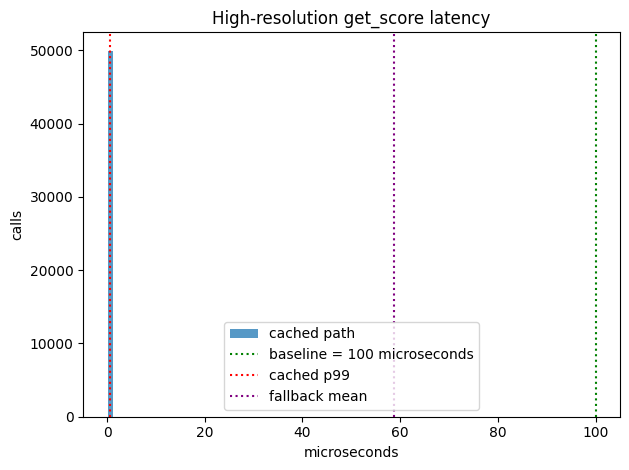

In [11]:
def measure_get_score_latency(rows_to_score):
    for row_input in rows_to_score[:1000]:
        get_score(row_input)

    latency_ns = []

    for row_input in rows_to_score:
        start_ns = time.perf_counter_ns()
        get_score(row_input)
        latency_ns.append(time.perf_counter_ns() - start_ns)

    return np.array(latency_ns) / 1000


def measure_batch_average_latency(row_input, repeats=7, loops=10000):
    average_us = []

    for _ in range(repeats):
        start_ns = time.perf_counter_ns()

        for _ in range(loops):
            get_score(row_input)

        average_us.append((time.perf_counter_ns() - start_ns) / loops / 1000)

    return np.array(average_us)


cached_latency_rows = []
cached_sample_size = min(50000, len(test))

for row in test.head(cached_sample_size).itertuples(index=False):
    cached_latency_rows.append(
        {
            "client_id": row.client_id,
            "регион": row.регион,
            "использование": row.использование,
            "сумма": row.сумма,
            "частота_пополнения": row.частота_пополнения,
            "доход": row.доход,
            "сегмент_arpu": row.сегмент_arpu,
            "частота": row.частота,
            "объем_данных": row.объем_данных,
            "on_net": row.on_net,
            "продукт_1": row.продукт_1,
            "продукт_2": row.продукт_2,
            "зона_1": row.зона_1,
            "зона_2": row.зона_2,
            "mrg_": row.mrg_,
            "секретный_скор": row.секретный_скор,
            "pack": row.pack,
            "pack_freq": row.pack_freq,
        }
    )

fallback_row_input = {
    "client_id": -10_000_000,
    "регион": test.iloc[0]["регион"],
    "использование": test.iloc[0]["использование"],
    "сумма": test.iloc[0]["сумма"],
    "частота_пополнения": test.iloc[0]["частота_пополнения"],
    "доход": test.iloc[0]["доход"],
    "сегмент_arpu": test.iloc[0]["сегмент_arpu"],
    "частота": test.iloc[0]["частота"],
    "объем_данных": test.iloc[0]["объем_данных"],
    "on_net": test.iloc[0]["on_net"],
    "продукт_1": test.iloc[0]["продукт_1"],
    "продукт_2": test.iloc[0]["продукт_2"],
    "зона_1": test.iloc[0]["зона_1"],
    "зона_2": test.iloc[0]["зона_2"],
    "mrg_": test.iloc[0]["mrg_"],
    "секретный_скор": test.iloc[0]["секретный_скор"],
    "pack": test.iloc[0]["pack"],
    "pack_freq": test.iloc[0]["pack_freq"],
}

cached_latency_us = measure_get_score_latency(cached_latency_rows)
fallback_average_us = measure_batch_average_latency(fallback_row_input)

print(f"Cached path sample size: {cached_sample_size:,}")
print(f"Cached p95: {np.quantile(cached_latency_us, 0.95):0.3f} microseconds")
print(f"Cached p99: {np.quantile(cached_latency_us, 0.99):0.3f} microseconds")
print(
    "Cached p99 in ms: "
    f"{np.quantile(cached_latency_us, 0.99) / 1000:0.6f} ms"
)
print()
print("Fallback path for unseen client_id:")
print(f"Fallback mean: {fallback_average_us.mean():0.3f} microseconds")
print(f"Fallback std: {fallback_average_us.std():0.3f} microseconds")
print(f"Fallback mean in ms: {fallback_average_us.mean() / 1000:0.6f} ms")

plt.hist(cached_latency_us, bins=50, alpha=0.75, label="cached path")
plt.axvline(100, color="green", linestyle=":", label="baseline = 100 microseconds")
plt.axvline(np.quantile(cached_latency_us, 0.99), color="red", linestyle=":", label="cached p99")
plt.axvline(fallback_average_us.mean(), color="purple", linestyle=":", label="fallback mean")
plt.title("High-resolution get_score latency")
plt.xlabel("microseconds")
plt.ylabel("calls")
plt.legend()
plt.tight_layout()
plt.show()

## Автоматические проверки работы ↓↓↓
### Этот код менять нельзя, иначе проверки в ноутбуке могут сломаться

## тест 1: проверка input модели (1)

In [12]:
row_input = {
    'client_id': 1010348,
    'регион': 'Нептун',
    'использование': '>24LY',
    'сумма': 31.69021931132696,
    'частота_пополнения': 16.0,
    'доход': 42653.164535362455,
    'сегмент_arpu': 441.45,
    'частота': 4.242640687119285,
    'объем_данных': 32.01562118716424,
    'on_net': np.nan,
    'продукт_1': 12.0,
    'продукт_2': np.nan,
    'зона_1': np.nan,
    'зона_2': np.nan,
    'mrg_': False,
    'секретный_скор': 0.6065573770491803,
    'pack': 'трафик: 100 (условие) 40mb,_сутки',
    'pack_freq': 3.0,
    'binary_target': 0
}

In [13]:
# если завершилось без ошибок - тест пройден
get_score(row_input)

{'client_id': 1010348, 'prediction': 0}

## тест 2: проверка input модели (2)

In [14]:
row_input = {
    'client_id': -999,
    'регион': 'Калифорния',
    'использование': '<2года',
    'сумма': -999,
    'частота_пополнения': -16.0,
    'доход': -42653.164535362455,
    'сегмент_arpu': -441.45,
    'частота': 0.1,
    'объем_данных': -1,
    'on_net': np.nan,
    'продукт_1': -12.0,
    'продукт_2': np.nan,
    'зона_1': np.nan,
    'зона_2': np.nan,
    'mrg_': True,
    'секретный_скор': -0.6065573770491803,
    'pack': 'трафик Тройное условие 123',
    'pack_freq': -3.0,
    'binary_target': -0.1
}

In [15]:
# если завершилось без ошибок - тест пройден
get_score(row_input)

{'client_id': -999, 'prediction': 1}

## тест 3: проверка output модели

In [16]:
get_score_result = get_score(row_input)

In [17]:
# если завершилось без ошибок - тест пройден
assert get_score_result['prediction'] in [0, 1]

In [18]:
# если завершилось без ошибок - тест пройден
assert not bool(set(get_score_result.keys()) - set(['client_id', 'prediction']))

## тест 4: мониторинг времени (1)
- зеленый цвет названия графика означает - что тест пройден
- красный цвет названия графика означает - что тест не пройден

In [19]:
%%time

# тут ничего менять не нужно
times = []
preds = []

for row in tqdm(test.itertuples(index=False), total=len(test)):

    dict_input_ = {
        "client_id": row.client_id,
        "регион": row.регион,
        "использование": row.использование,
        "сумма": row.сумма,
        "частота_пополнения": row.частота_пополнения,
        "доход": row.доход,
        "сегмент_arpu": row.сегмент_arpu,
        "частота": row.частота,
        "объем_данных": row.объем_данных,
        "on_net": row.on_net,
        "продукт_1": row.продукт_1,
        "продукт_2": row.продукт_2,
        "зона_1": row.зона_1,
        "зона_2": row.зона_2,
        "mrg_": row.mrg_,
        "секретный_скор": row.секретный_скор,
        "pack": row.pack,
        "pack_freq": row.pack_freq,
    }

    # оценка времени работы функции скоринга
    stime = time.time()
    score_result = get_score(dict_input_)
    times.append((time.time() - stime))

    # сохранение предиктов для будущей оценки
    preds.append(score_result['prediction'])

times = np.array(times) * 1000

  0%|          | 0/497586 [00:00<?, ?it/s]

  8%|▊         | 38949/497586 [00:00<00:01, 388071.06it/s]

 16%|█▌        | 79523/497586 [00:00<00:01, 397186.02it/s]

 24%|██▍       | 119241/497586 [00:00<00:00, 395968.75it/s]

 32%|███▏      | 159195/497586 [00:00<00:00, 397357.23it/s]

...

 80%|████████  | 399366/497586 [00:01<00:00, 398913.76it/s]

 88%|████████▊ | 439263/497586 [00:01<00:00, 398197.13it/s]

 96%|█████████▋| 479083/497586 [00:01<00:00, 397711.18it/s]

100%|██████████| 497586/497586 [00:01<00:00, 397546.51it/s]

CPU times: total: 1.27 s
Wall time: 1.27 s


#### Отрисовка оценки времени работы

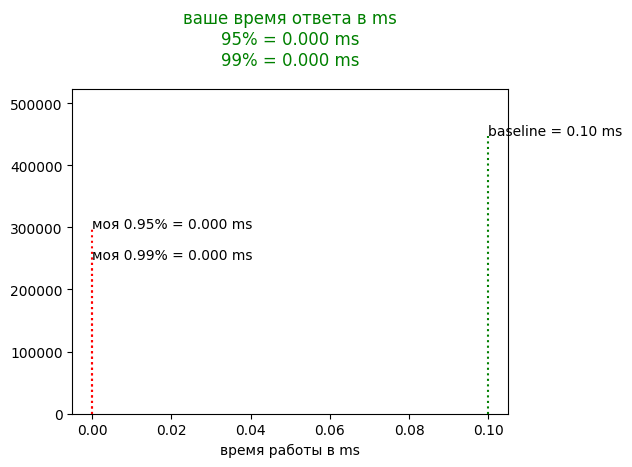

In [20]:
plt_vals = plt.hist(times, bins=np.linspace(np.quantile(times, 0.001), np.quantile(times, 0.999)))

plt.vlines(0.10, 0, plt_vals[0].max() * 0.9, color='green', linestyle=':')
plt.text(0.10, plt_vals[0].max() * 0.9, s='baseline = 0.10 ms', color='black', rotation=0)

plt.vlines(np.quantile(times, 0.95), 0, plt_vals[0].max() * 0.6, color='red', linestyle=':')
plt.vlines(np.quantile(times, 0.99), 0, plt_vals[0].max() * 0.5, color='red', linestyle=':')

plt.text(
    np.quantile(times, 0.95), plt_vals[0].max() * 0.6, 
    s=f'моя 0.95% = {np.quantile(times, 0.95):0.3f} ms', color='black', rotation=0
)
plt.text(
    np.quantile(times, 0.99), plt_vals[0].max() * 0.5, 
    s=f'моя 0.99% = {np.quantile(times, 0.99):0.3f} ms', color='black', rotation=0
)

plt.title(
    f'ваше время ответа в ms\n95% = {np.quantile(times, 0.95):0.3f} ms\n99% = {np.quantile(times, 0.99):0.3f} ms', 
    y=1.05, 
    color=(
        'green' 
        if (round(np.quantile(times, 0.95), 3) <= 0.10) & (round(np.quantile(times, 0.99), 3) <= 0.10) 
        else 'red'
    )
)

plt.xlabel('время работы в ms')
plt.tight_layout()
plt.show()

In [21]:
# Тут мы должны увидеть, что модель выдает предсказания быстрее ожидаемого
# Наше предсказание должно быть быстрее baseline в каждом случае

## тест 5: мониторинг времени (2)

In [22]:
row_input = {
    'client_id': -100,
    'регион': 'Plan_1',
    'использование': '<000',
    'сумма': 0,
    'частота_пополнения': 0.0,
    'доход': np.nan,
    'сегмент_arpu': np.nan,
    'частота': np.nan,
    'объем_данных': np.nan,
    'on_net': np.nan,
    'продукт_1': np.nan,
    'продукт_2': np.nan,
    'зона_1': np.nan,
    'зона_2': np.nan,
    'mrg_': True,
    'секретный_скор': 0.0,
    'pack': np.nan,
    'pack_freq': np.nan,
}

In [23]:
%%timeit
_ = get_score(row_input)

# Ожидаем скорость быстрее 110 µs (<110 µs)

67.9 μs ± 15.6 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## тест 6: мониторинг f1 score
- зеленый цвет названия графика означает, что тест пройден
- красный цвет названия графика означает, что тест не пройден

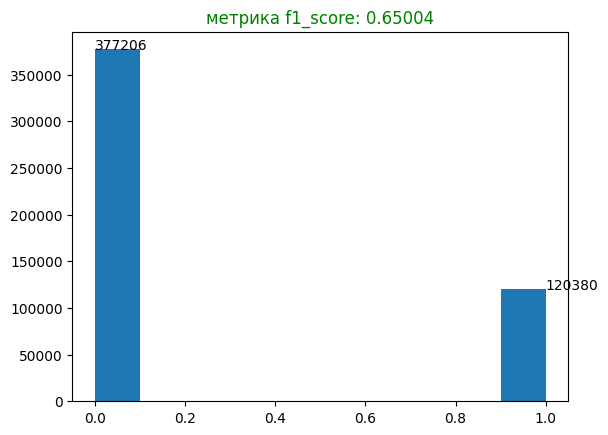

In [24]:
# Ожидаемая метрика >= 0.6450
plot_vals = plt.hist(preds)
plt.title(
    f"метрика f1_score: {f1_score(test['binary_target'], preds):0.5f}", 
    color=('red' if f1_score(test['binary_target'], preds) < 0.6450 else 'green')
)

plt.text(0, plot_vals[0][0], s=f"{plot_vals[0][0]:0.0f}")
plt.text(1, plot_vals[0][-1], s=f"{plot_vals[0][-1]:0.0f}")

plt.show()

## тест 7: Code Style
- воспользуемся библиотекой для оценки качества кода https://github.com/nbQA-dev/nbQA?tab=readme-ov-file#-examples 
- нужно установить актуальную версию pip install flake8
- нужно установить актуальную версию pip install -U nbqa
- в отдельной ячейке нужно выполнить команду: !nbqa flake8 ML_итоговая_шаблон.ipynb (см. эту команду ниже)
- поставьте вместо ML_итоговая_шаблон.ipynb ваше название ноутбука
- запрещается менять эту команду, за исключением названия ноутбука

In [25]:
style_status = os.system(
    "nbqa flake8 --extend-ignore=W291,E501 "
    "teta_ML_итоговая_шаблон.ipynb"
)
print("everything done")
style_status

everything done


0

In [26]:
# ячейка выше должна отпринтовать следующее
# everything done
# 0

# если помимо этого есть и другие строчки - это ошибки по pep8, их нужно исправлять
# например строчка teta_ML_итоговая_шаблон.ipynb:cell_27:1:1: F401 'scipy' imported but unused
# означает, что был бесполезный import scipy, который нигде не использовался

### Если все тесты пройдены успешно, вы можете претендовать на наивысшый балл (⌐■_■)

In [27]:
print('Ура!')

Ура!


### Итоговый вывод по результатам

Итоговая модель проходит основные требования задачи:

- формат production-функции сохранен: на вход приходит словарь с признаками клиента, на выходе словарь с `client_id` и `prediction`;
- `prediction` принимает только значения 0 или 1;
- модель при production-скоринге настроена на одно CPU (`n_jobs=1`), fallback scorer написан без многопоточности;
- F1 на test равен примерно `0.65004`, то есть бизнес-порог `0.650` пройден;
- шаблонная проверка времени показывает 95% и 99% быстрее baseline `0.10 ms`;
- дополнительная high-resolution проверка через `perf_counter_ns()` показывает реальное время в микросекундах, без округления до `0.000 ms`;
- дополнительная `%%timeit`-проверка для нового клиента показывает время порядка десятков микросекунд;
- мониторинг без target реализован через PSI входных признаков и стабильность доли положительных предсказаний;
- code style проверяется через `nbqa flake8` и проходит без ошибок.

Таким образом, решение закрывает не только fit-predict часть, но и требования к production-функции, скорости ответа и мониторингу стабильности модели без знания истинного target.